In [1]:
%matplotlib widget

# Perform laterally constrained inversion on Field data Ackerdijkse Plassen

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling_field, LCModelling
from showStitched import showStitchedModels


/tmp/ipykernel_3282033/772853352.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# 1. Load data

Dataframe = pd.DataFrame(np.load('data/Field_data.npy'),
                        columns = ['X','Y','Position','Z','H2Q','H4Q','H8Q',
                                   'V2Q','V4Q','V8Q','P2Q','P4Q','P8Q',
                                   'H4IP','H8IP','V4IP','V8IP'])

In [4]:
# Obtain H and V quadrature and in-phase measurements
# For in-phase we only use measurements for offsets > 4 m
data = np.array(pd.concat([Dataframe.loc[:,'H2Q':'V8Q'], Dataframe.loc[:,'H4IP':]], axis=1))
npos = len(data) # number of 1D models
nlay = 2 # number of layers

nM=50 # number of measurements per line

nLines = int(npos/50)

In [5]:
# Define an initial model

model_ini = np.ones((nM,3))
model_ini[:,0] = model_ini[:,0]*3   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.1 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.1 # initial sigma_2

# Perform laterally constrained inversion in each line

In [6]:
model_inv_full = []
response_full = []

for nL in range(nLines):

    data_L = data[nL*nM:(nL+1)*nM]
    
    LCI = LCModelling(FDEM1DModelling_field)
    
    LCI.initJacobian(dataVals=data_L, nLay=nlay)
    LCI.createJacobian(model_ini)
    LCI.constraint_matrix(data_L, nLay=nlay)
    LCI.normalization(data_L, cWeight_1=1, cWeight_2=1, nLay=nlay)
    LCI.createWeight(data_L, cWeight_1=1, cWeight_2=1, nLay=nlay)
    LCI.createConstraints()
    
    # Set transforms
    #transData = pg.trans.TransLog()
    transThk = pg.trans.TransLogLU(0.1,5)
    transSig = pg.trans.TransLogLU(1/1000,500/1000)
    
    LCI.region(1).setTransModel(transThk)
    LCI.region(2).setTransModel(transSig)

    # Create data vector
    data_vector = data_L.ravel()
    relativeError = np.ones_like(data_vector)*1e-3 
    
    # Run inversion
    inv = pg.Inversion(LCI)
    #inv.dataTrans = transData
    model_inv = inv.run(data_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1 )
    
    model_inv_full.append(model_inv)
    response_full.append(inv.response)
    

Inversion is normalized
Jacobian size: 490 147 500


03/10/24 - 15:03:28 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/10/24 - 15:03:28 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f276495aca0>
Inversion is normalized
Jacobian size: 490 147 500


03/10/24 - 15:03:30 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/10/24 - 15:03:31 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f276307ebb0>
Inversion is normalized
Jacobian size: 490 147 500


...

cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f276307c9f0>
Inversion is normalized
Jacobian size: 490 147 500


03/10/24 - 15:04:57 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/10/24 - 15:04:57 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f276495a1b0>
Inversion is normalized
Jacobian size: 490 147 500


03/10/24 - 15:05:01 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/10/24 - 15:05:01 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 147
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f2763002cf0>


In [7]:
model_inv = np.array(model_inv_full).reshape(nLines*nM,3)
responses = np.array(response_full).reshape(nLines*nM,10)

In [8]:
Model_inv_frame =pd.DataFrame(model_inv, columns= ['h_1', 's_1', 's_2'])

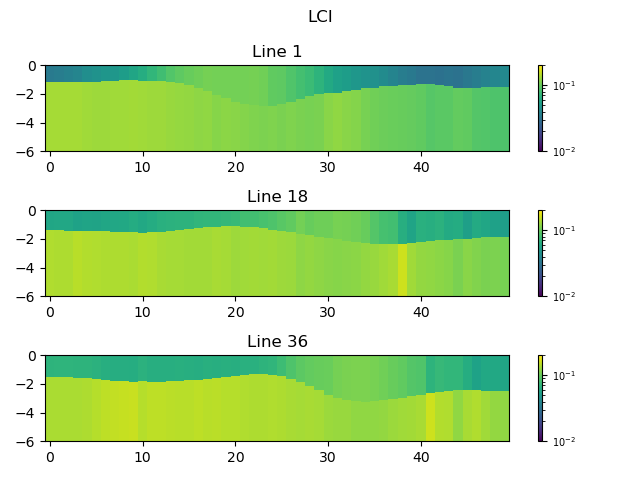

In [20]:
fig, ax = plt.subplots(3,1)

showStitchedModels(model_inv[0:50], ax=ax[0], zMax=6, cMin=10/1000, cMax=200/1000)
ax[0].set_title('Line 1')

showStitchedModels(model_inv[900:950], ax=ax[1], zMax=6, cMin=10/1000, cMax=200/1000)
ax[1].set_title('Line 18')

showStitchedModels(model_inv[1800:], ax=ax[2], zMax=6, cMin=10/1000, cMax=200/1000)
ax[2].set_title('Line 36')

fig.suptitle('LCI')
plt.tight_layout()

In [10]:
X = Dataframe['X']
Y = Dataframe['Y']
h_1 = Model_inv_frame['h_1']
s_1 = Model_inv_frame['s_1']*1000
s_2 = Model_inv_frame['s_2']*1000

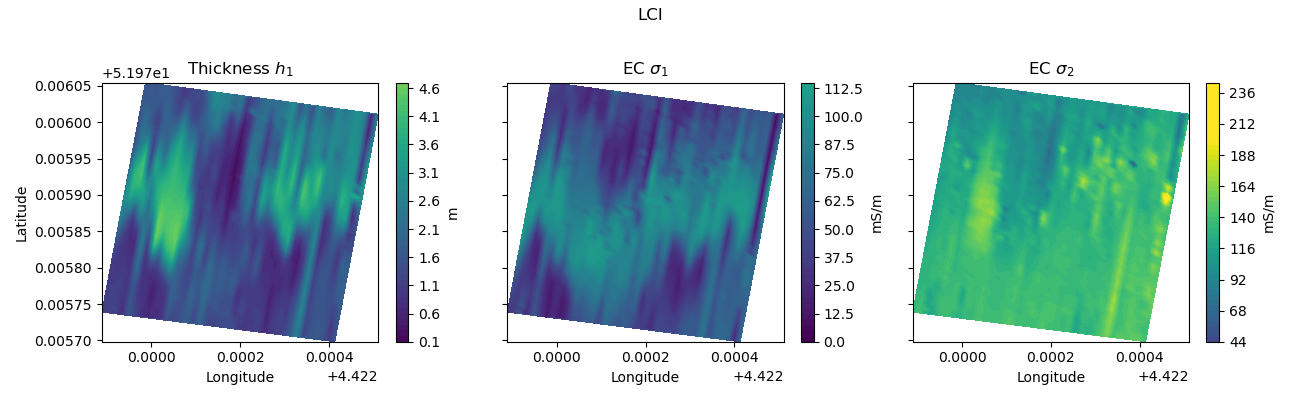

In [19]:
fig, ax = plt.subplots(1,3, figsize=(13,4), sharey=True)

cb0 = ax[0].tricontourf(X, Y, h_1, vmin=0, vmax=6, levels=50, cmap='viridis')
ax[0].set_title('Thickness $h_1$')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')


cb1 = ax[1].tricontourf(X, Y, s_1, vmin=1, vmax=200, levels=50, cmap='viridis')
ax[1].set_title('EC $\sigma_1$')
ax[1].set_xlabel('Longitude')

cb2 = ax[2].tricontourf(X, Y, s_2, vmin=1, vmax=200, levels=50, cmap='viridis')
ax[2].set_title('EC $\sigma_2$')
ax[2].set_xlabel('Longitude')

fig.colorbar(cb0, ax=ax[0], label='m')
fig.colorbar(cb1, ax=ax[1], label='mS/m')
fig.colorbar(cb2, ax=ax[2], label='mS/m')

fig.suptitle('LCI')

plt.tight_layout()

